# Customer Churn Prediction (Machine Learning)

This notebook builds an end-to-end **customer churn prediction** pipeline using a real-world telecom churn dataset.

**What you’ll see in this notebook**
- Load a real dataset (auto-download if not available)
- Data cleaning (including `TotalCharges` fix)
- Exploratory analysis (EDA)
- Preprocessing with `ColumnTransformer`
- Train & compare models (Logistic Regression, Random Forest)
- Evaluation (Confusion Matrix, ROC-AUC, PR curve)
- Business insights + recommendations
- Save the best model for reuse

**Dataset source (public):** IBM Telco Customer Churn CSV (downloaded directly in this notebook).


In [2]:
# ============================================================
# 1) Imports + settings
# ============================================================
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score
)

import joblib

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

# Ensure plots show in notebooks
%matplotlib inline

print("Ready ✅")

Ready ✅


## 2) Load the real dataset (auto-download)

This notebook will:
1. Look for the dataset locally in the same folder
2. If not found, **download it automatically** from IBM’s public repo


In [4]:
# ============================================================
# 2) Load the real dataset (auto-download)
# ============================================================
DATA_FILE = "Telco-Customer-Churn.csv"

# IBM public raw CSV (stable direct link)
DATA_URL = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"

if not os.path.exists(DATA_FILE):
    print("Dataset not found locally. Downloading...")
    df = pd.read_csv(DATA_URL)
    df.to_csv(DATA_FILE, index=False)
    print(f"Downloaded and saved as: {DATA_FILE}")
else:
    print(f"Found local dataset: {DATA_FILE}")
    df = pd.read_csv(DATA_FILE)

print("Shape:", df.shape)
df.head()

Found local dataset: Telco-Customer-Churn.csv
Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 3) Quick data checks

We’ll confirm:
- missing values
- data types
- target distribution (`Churn`)


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
# Missing values per column
df.isna().sum().sort_values(ascending=False).head(10)

customerID          0
DeviceProtection    0
TotalCharges        0
MonthlyCharges      0
PaymentMethod       0
PaperlessBilling    0
Contract            0
StreamingMovies     0
StreamingTV         0
TechSupport         0
dtype: int64

In [8]:
# Target distribution
df["Churn"].value_counts(normalize=True).rename("proportion")

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

## 4) Clean & prepare data

Key cleaning step in this dataset:
- `TotalCharges` sometimes appears as blank strings → convert to numeric
- Drop `customerID` (identifier, not predictive)
- Encode target: `Churn` → 1/0


In [10]:
# Make a clean copy
df_clean = df.copy()

# Remove ID column (doesn't help prediction)
if "customerID" in df_clean.columns:
    df_clean = df_clean.drop(columns=["customerID"])

# Convert TotalCharges to numeric (blank strings become NaN)
df_clean["TotalCharges"] = pd.to_numeric(df_clean["TotalCharges"], errors="coerce")

# Drop rows where TotalCharges is missing after conversion (small number of rows)
df_clean = df_clean.dropna(subset=["TotalCharges"]).reset_index(drop=True)

# Encode target
df_clean["Churn"] = df_clean["Churn"].map({"Yes": 1, "No": 0}).astype(int)

print("Clean shape:", df_clean.shape)
df_clean.head()

Clean shape: (7032, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


## 5) Simple EDA (quick, interview-friendly)

We’ll look at churn rate by:
- Contract type
- Tenure buckets
- Monthly charges buckets


In [12]:
# Churn rate by Contract
churn_by_contract = (
    df_clean.groupby("Contract")["Churn"]
    .mean()
    .sort_values(ascending=False)
)
churn_by_contract

Contract
Month-to-month    0.427097
One year          0.112772
Two year          0.028487
Name: Churn, dtype: float64

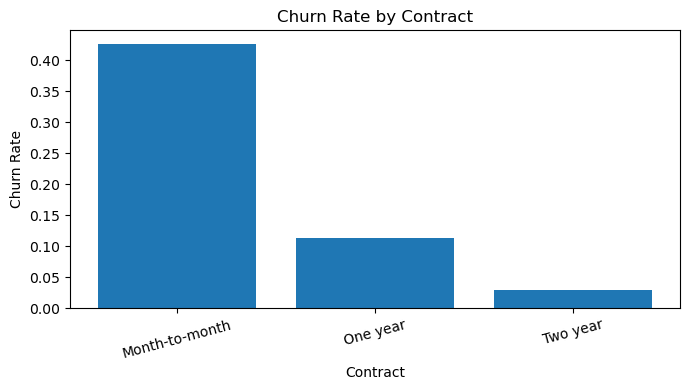

In [13]:
plt.figure(figsize=(7,4))
plt.bar(churn_by_contract.index, churn_by_contract.values)
plt.title("Churn Rate by Contract")
plt.xlabel("Contract")
plt.ylabel("Churn Rate")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [14]:
# Tenure buckets
df_clean["tenure_bucket"] = pd.cut(
    df_clean["tenure"],
    bins=[0, 6, 12, 24, 48, 72],
    labels=["0-6", "7-12", "13-24", "25-48", "49-72"],
    include_lowest=True
)

churn_by_tenure = df_clean.groupby("tenure_bucket")["Churn"].mean()
churn_by_tenure

tenure_bucket
0-6      0.533333
7-12     0.358865
13-24    0.287109
25-48    0.203890
49-72    0.095132
Name: Churn, dtype: float64

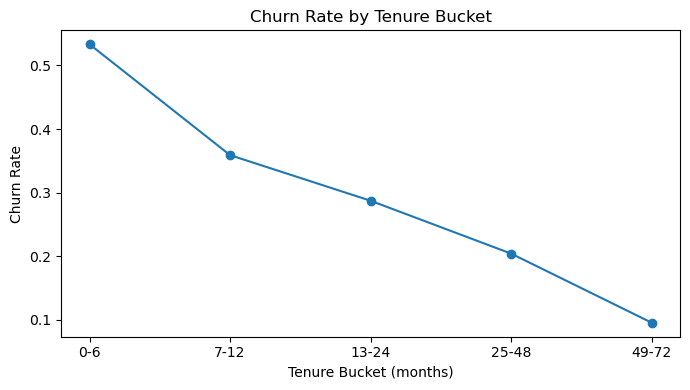

In [15]:
plt.figure(figsize=(7,4))
plt.plot(churn_by_tenure.index.astype(str), churn_by_tenure.values, marker="o")
plt.title("Churn Rate by Tenure Bucket")
plt.xlabel("Tenure Bucket (months)")
plt.ylabel("Churn Rate")
plt.tight_layout()
plt.show()

In [16]:
# MonthlyCharges buckets
df_clean["mc_bucket"] = pd.qcut(df_clean["MonthlyCharges"], 5, duplicates="drop")
churn_by_mc = df_clean.groupby("mc_bucket")["Churn"].mean()
churn_by_mc

mc_bucket
(18.249, 25.05]    0.091808
(25.05, 58.92]     0.249821
(58.92, 79.15]     0.299647
(79.15, 94.3]      0.359687
(94.3, 118.75]     0.329286
Name: Churn, dtype: float64

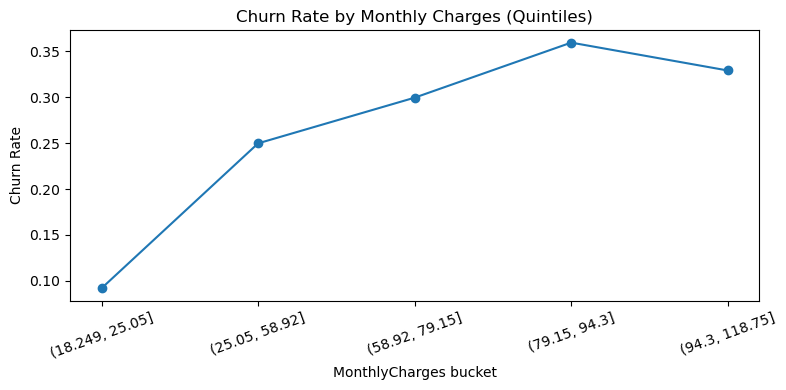

In [17]:
plt.figure(figsize=(8,4))
plt.plot([str(x) for x in churn_by_mc.index], churn_by_mc.values, marker="o")
plt.title("Churn Rate by Monthly Charges (Quintiles)")
plt.xlabel("MonthlyCharges bucket")
plt.ylabel("Churn Rate")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### Additional EDA Visualizations
These visuals help explain *who churns and why* in an interview-friendly way.

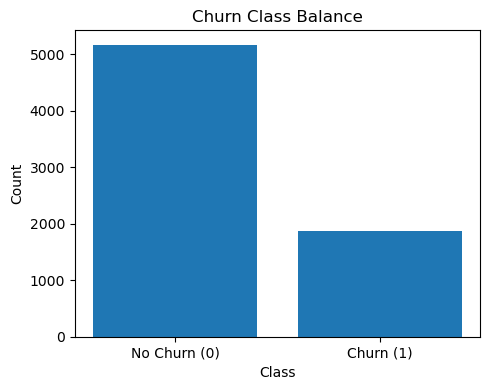

Churn
0    5163
1    1869
Name: count, dtype: int64

In [19]:
# Churn class balance (counts)
churn_counts = df_clean["Churn"].value_counts().sort_index()
labels = ["No Churn (0)", "Churn (1)"]

plt.figure(figsize=(5,4))
plt.bar(labels, churn_counts.values)
plt.title("Churn Class Balance")
plt.xlabel("Class")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

churn_counts

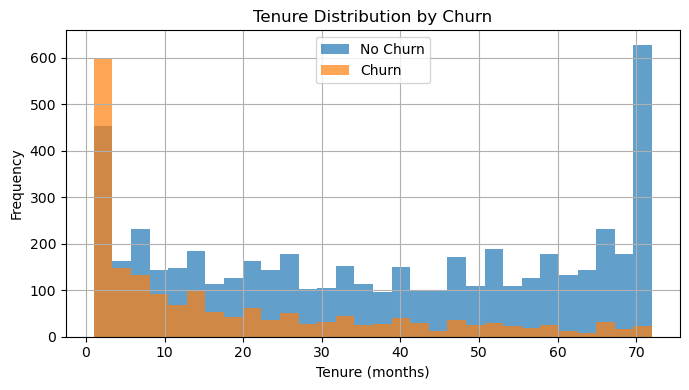

In [20]:
# Tenure distribution by churn
plt.figure(figsize=(7,4))
df_clean[df_clean["Churn"]==0]["tenure"].hist(bins=30, alpha=0.7, label="No Churn")
df_clean[df_clean["Churn"]==1]["tenure"].hist(bins=30, alpha=0.7, label="Churn")
plt.title("Tenure Distribution by Churn")
plt.xlabel("Tenure (months)")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

<Figure size 600x400 with 0 Axes>

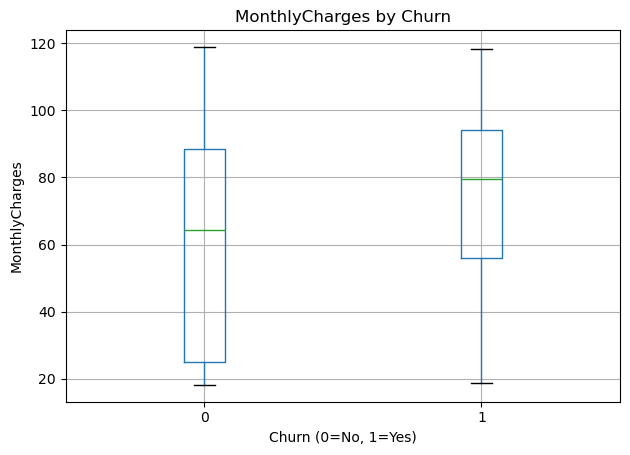

In [21]:
# MonthlyCharges boxplot by churn
plt.figure(figsize=(6,4))
df_clean.boxplot(column="MonthlyCharges", by="Churn")
plt.title("MonthlyCharges by Churn")
plt.suptitle("")  # remove automatic title
plt.xlabel("Churn (0=No, 1=Yes)")
plt.ylabel("MonthlyCharges")
plt.tight_layout()
plt.show()

<Figure size 600x400 with 0 Axes>

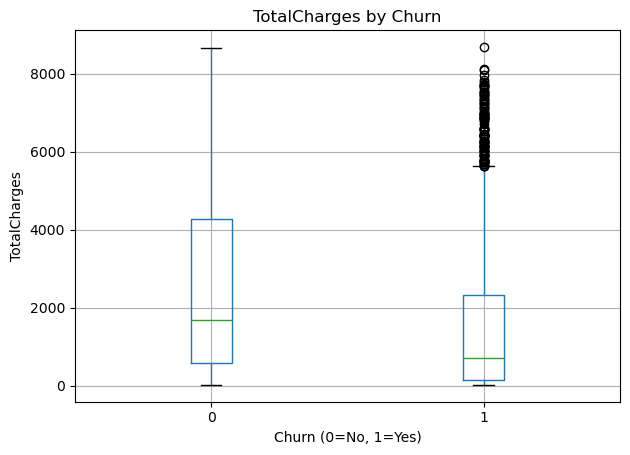

In [22]:
# TotalCharges boxplot by churn
plt.figure(figsize=(6,4))
df_clean.boxplot(column="TotalCharges", by="Churn")
plt.title("TotalCharges by Churn")
plt.suptitle("")
plt.xlabel("Churn (0=No, 1=Yes)")
plt.ylabel("TotalCharges")
plt.tight_layout()
plt.show()

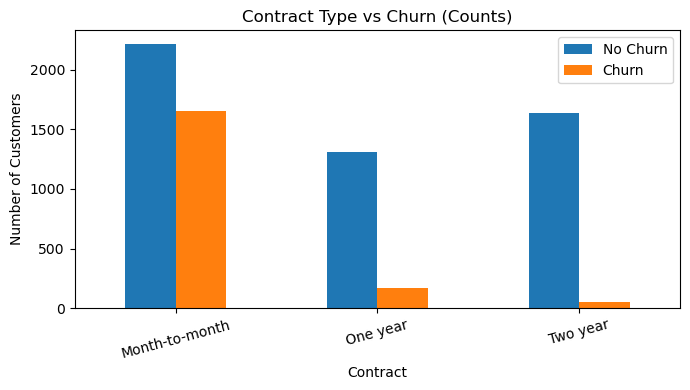

,No Churn,Churn
Contract,,
Month-to-month,2220,1655
One year,1306,166
Two year,1637,48


In [23]:
# Contract vs Churn (counts)
ct = pd.crosstab(df_clean["Contract"], df_clean["Churn"])
ct.columns = ["No Churn", "Churn"]

ct.plot(kind="bar", figsize=(7,4))
plt.title("Contract Type vs Churn (Counts)")
plt.xlabel("Contract")
plt.ylabel("Number of Customers")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

ct

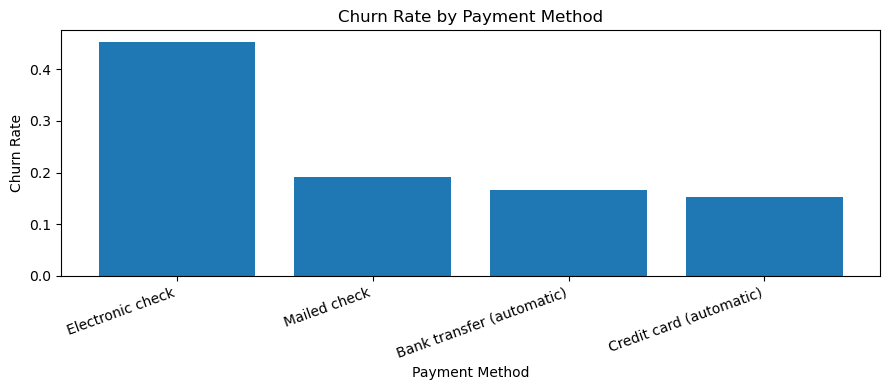

PaymentMethod
Electronic check             0.452854
Mailed check                 0.192020
Bank transfer (automatic)    0.167315
Credit card (automatic)      0.152531
Name: Churn, dtype: float64

In [24]:
# PaymentMethod churn rate (top business driver)
pm_churn = (
    df_clean.groupby("PaymentMethod")["Churn"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(9,4))
plt.bar(pm_churn.index, pm_churn.values)
plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

pm_churn

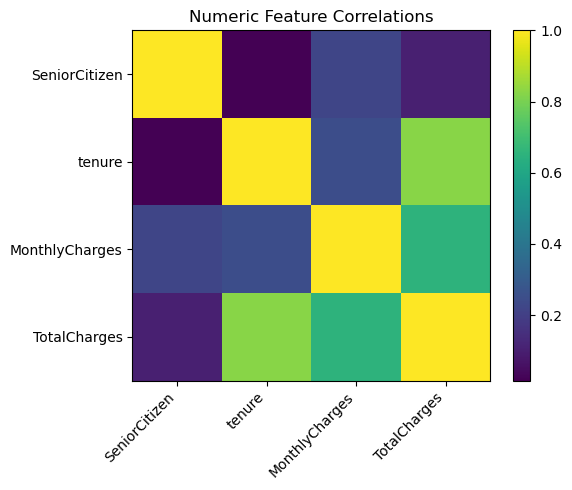

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
SeniorCitizen,1.000000,0.015683,0.219874,0.102411
tenure,0.015683,1.000000,0.246862,0.825880
MonthlyCharges,0.219874,0.246862,1.000000,0.651065
TotalCharges,0.102411,0.825880,0.651065,1.000000


In [25]:
# Correlation heatmap (numeric features)
num_for_corr = df_clean.select_dtypes(include=["number"]).drop(columns=["Churn"], errors="ignore")
corr = num_for_corr.corr()

plt.figure(figsize=(6,5))
plt.imshow(corr, aspect="auto")
plt.title("Numeric Feature Correlations")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.columns)), corr.columns)
plt.colorbar()
plt.tight_layout()
plt.show()

corr

## 6) Build ML pipeline (preprocessing + model)

We’ll use:
- Numeric: `StandardScaler`
- Categorical: `OneHotEncoder(handle_unknown="ignore")`
- Models:
  - Logistic Regression (baseline, explainable)
  - Random Forest (non-linear, stronger baseline)


In [27]:
# Split features/target
X = df_clean.drop(columns=["Churn"])
y = df_clean["Churn"]

# Train/test split (stratified keeps churn ratio consistent)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Identify column types
num_cols = X.select_dtypes(include=["number"]).columns.tolist()
cat_cols = [c for c in X.columns if c not in num_cols]

print("Numeric columns:", num_cols)
print("Categorical columns:", cat_cols[:10], "..." if len(cat_cols) > 10 else "")

Numeric columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport'] ...


In [28]:
# Preprocessor
preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ],
    remainder="drop"
)

# Models
log_reg = LogisticRegression(max_iter=2000)
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

pipe_lr = Pipeline(steps=[("prep", preprocess), ("model", log_reg)])
pipe_rf = Pipeline(steps=[("prep", preprocess), ("model", rf)])

print("Pipelines ready ✅")

Pipelines ready ✅


## 7) Train & evaluate

We’ll report:
- Confusion matrix
- Precision / Recall / F1
- ROC-AUC (main ranking metric)
- Precision-Recall AUC (useful when churn is imbalanced)


In [30]:
def evaluate_model(name, model, X_test, y_test):
    # Predict class + probability for positive class
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    print("="*70)
    print(f"MODEL: {name}")
    print("="*70)

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    cm_df = pd.DataFrame(
        cm,
        index=["Actual 0 (No Churn)", "Actual 1 (Churn)"],
        columns=["Pred 0", "Pred 1"]
    )
    display(cm_df)

    # Classification report
    print(classification_report(y_test, y_pred, digits=3))

    # ROC-AUC
    roc = roc_auc_score(y_test, y_prob)
    print(f"ROC-AUC: {roc:.4f}")

    # PR-AUC
    ap = average_precision_score(y_test, y_prob)
    print(f"PR-AUC (Average Precision): {ap:.4f}")

    # ROC curve plot
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.figure(figsize=(6,4))
    plt.plot(fpr, tpr)
    plt.plot([0,1], [0,1], linestyle="--")
    plt.title(f"ROC Curve - {name} (AUC={roc:.3f})")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.tight_layout()
    plt.show()

    # Precision-Recall curve plot
    prec, rec, _ = precision_recall_curve(y_test, y_prob)
    plt.figure(figsize=(6,4))
    plt.plot(rec, prec)
    plt.title(f"Precision-Recall Curve - {name} (AP={ap:.3f})")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.tight_layout()
    plt.show()

    return roc, ap

MODEL: Logistic Regression


,Pred 0,Pred 1
Actual 0 (No Churn),922,111
Actual 1 (Churn),174,200


              precision    recall  f1-score   support

           0      0.841     0.893     0.866      1033
           1      0.643     0.535     0.584       374

    accuracy                          0.797      1407
   macro avg      0.742     0.714     0.725      1407
weighted avg      0.789     0.797     0.791      1407

ROC-AUC: 0.8376
PR-AUC (Average Precision): 0.6395


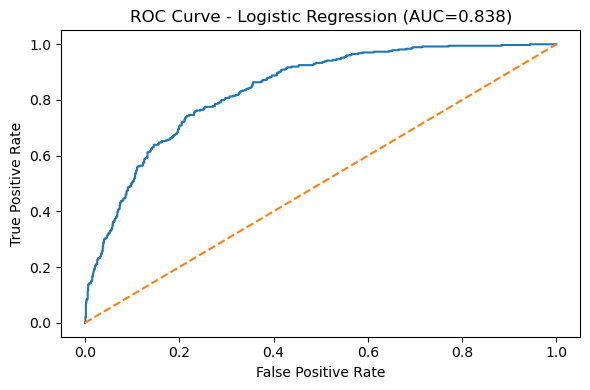

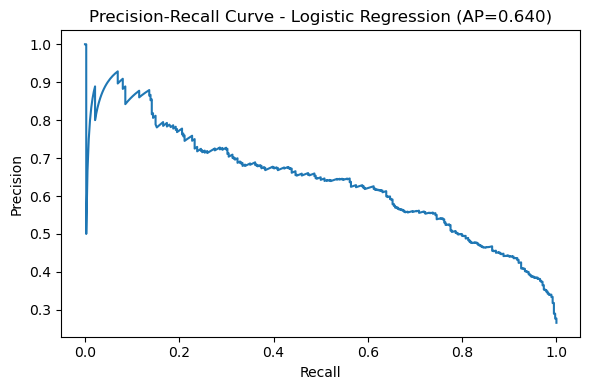

In [31]:
# Train Logistic Regression
pipe_lr.fit(X_train, y_train)
roc_lr, ap_lr = evaluate_model("Logistic Regression", pipe_lr, X_test, y_test)

MODEL: Random Forest


,Pred 0,Pred 1
Actual 0 (No Churn),929,104
Actual 1 (Churn),193,181


              precision    recall  f1-score   support

           0      0.828     0.899     0.862      1033
           1      0.635     0.484     0.549       374

    accuracy                          0.789      1407
   macro avg      0.732     0.692     0.706      1407
weighted avg      0.777     0.789     0.779      1407

ROC-AUC: 0.8185
PR-AUC (Average Precision): 0.5982


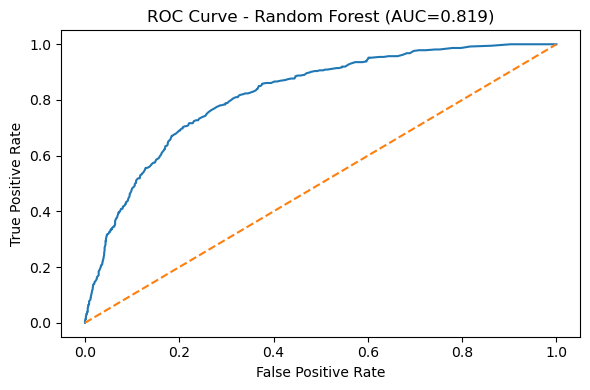

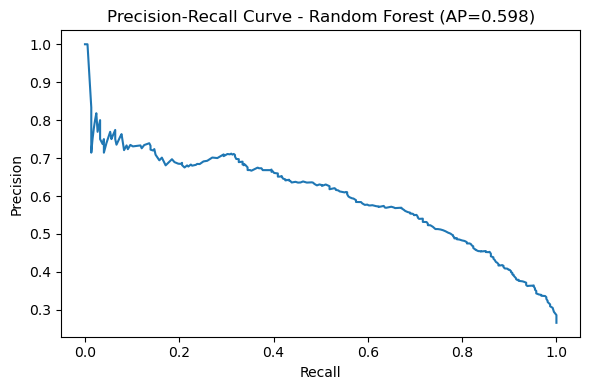

In [32]:
# Train Random Forest
pipe_rf.fit(X_train, y_train)
roc_rf, ap_rf = evaluate_model("Random Forest", pipe_rf, X_test, y_test)

## 8) Choose best model and save it

We’ll pick the model with the higher ROC-AUC (and check PR-AUC too), then save it to a `.pkl` file.


In [34]:
# Pick the best model by ROC-AUC
best_name, best_model = ("Random Forest", pipe_rf) if roc_rf >= roc_lr else ("Logistic Regression", pipe_lr)
print(f"Best model by ROC-AUC: {best_name}")

MODEL_FILE = "best_churn_model.pkl"
joblib.dump(best_model, MODEL_FILE)
print(f"Saved model to: {MODEL_FILE}")

Best model by ROC-AUC: Logistic Regression
Saved model to: best_churn_model.pkl


## 8.1) Extra visualizations: Confusion Matrix + Feature Importance
These are great screenshots for your report and great talking points for interviews.

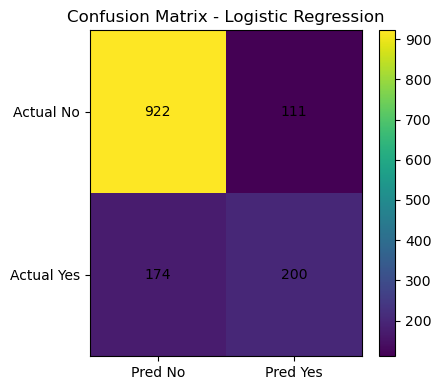

In [36]:
# Confusion matrix heatmap for the selected best model
y_pred_best = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(4.5,4))
plt.imshow(cm, aspect="auto")
plt.title(f"Confusion Matrix - {best_name}")
plt.xticks([0,1], ["Pred No", "Pred Yes"])
plt.yticks([0,1], ["Actual No", "Actual Yes"])
for (i, j), v in np.ndenumerate(cm):
    plt.text(j, i, str(v), ha="center", va="center")
plt.colorbar()
plt.tight_layout()
plt.show()

In [37]:
# Helper: get feature names after preprocessing (works for OneHotEncoder)
def get_feature_names_from_preprocessor(preprocessor: ColumnTransformer):
    feature_names = []

    # Each transformer: (name, transformer, columns)
    for name, transformer, cols in preprocessor.transformers_:
        if name == "remainder" and transformer == "drop":
            continue

        if hasattr(transformer, "get_feature_names_out"):
            # For OneHotEncoder
            try:
                fn = transformer.get_feature_names_out(cols)
            except TypeError:
                fn = transformer.get_feature_names_out()
            feature_names.extend(fn.tolist())
        else:
            # For StandardScaler or passthrough numeric columns
            if isinstance(cols, (list, tuple, np.ndarray)):
                feature_names.extend(list(cols))
            else:
                feature_names.append(cols)

    return feature_names

prep_fitted = best_model.named_steps["prep"]
feature_names = get_feature_names_from_preprocessor(prep_fitted)

len(feature_names), feature_names[:10]

(55,
 ['SeniorCitizen',
  'tenure',
  'MonthlyCharges',
  'TotalCharges',
  'gender_Female',
  'gender_Male',
  'Partner_No',
  'Partner_Yes',
  'Dependents_No',
  'Dependents_Yes'])

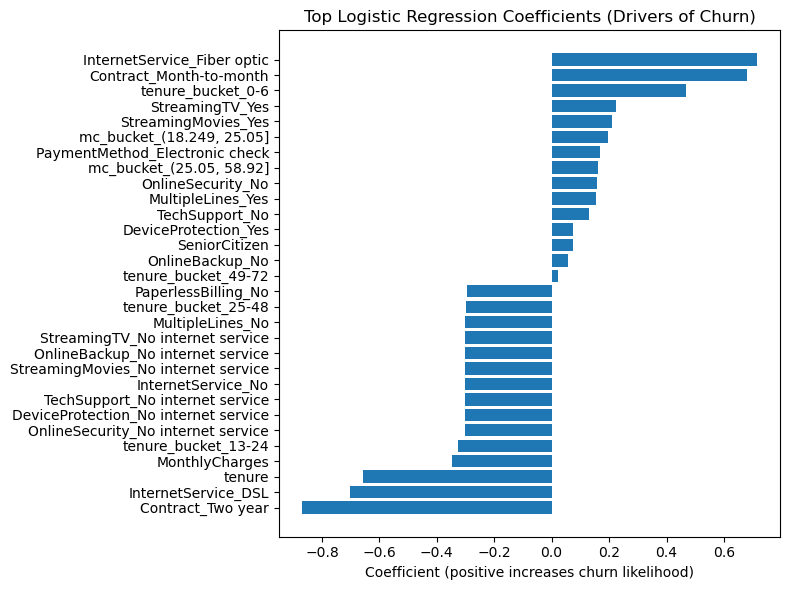

Contract_Two year                      -0.870242
InternetService_DSL                    -0.701513
tenure                                 -0.656558
MonthlyCharges                         -0.347616
tenure_bucket_13-24                    -0.327528
OnlineSecurity_No internet service     -0.302443
DeviceProtection_No internet service   -0.302443
TechSupport_No internet service        -0.302443
InternetService_No                     -0.302443
StreamingMovies_No internet service    -0.302443
OnlineBackup_No internet service       -0.302443
StreamingTV_No internet service        -0.302443
MultipleLines_No                       -0.300134
tenure_bucket_25-48                    -0.299018
PaperlessBilling_No                    -0.295268
tenure_bucket_49-72                     0.023264
OnlineBackup_No                         0.058053
SeniorCitizen                           0.073637
DeviceProtection_Yes                    0.075389
TechSupport_No                          0.130143
MultipleLines_Yes   

In [38]:
# Feature importance / coefficients (top drivers)
model_core = best_model.named_steps["model"]

if hasattr(model_core, "feature_importances_"):
    importances = pd.Series(model_core.feature_importances_, index=feature_names).sort_values(ascending=False)
    top = importances.head(20).sort_values(ascending=True)

    plt.figure(figsize=(8,5))
    plt.barh(top.index, top.values)
    plt.title(f"Top Feature Importances - {best_name}")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()

    display(importances.head(25))

elif hasattr(model_core, "coef_"):
    coefs = pd.Series(model_core.coef_[0], index=feature_names).sort_values()
    top_neg = coefs.head(15)
    top_pos = coefs.tail(15)

    top = pd.concat([top_neg, top_pos])

    plt.figure(figsize=(8,6))
    plt.barh(top.index, top.values)
    plt.title("Top Logistic Regression Coefficients (Drivers of Churn)")
    plt.xlabel("Coefficient (positive increases churn likelihood)")
    plt.tight_layout()
    plt.show()

    display(top)

else:
    print("This model type doesn't expose importances or coefficients.")

## 9) Business summary

- **Goal:** predict which customers are likely to churn so retention teams can act early.
- **High churn patterns:** month-to-month contracts, lower tenure customers, and higher monthly charges tend to churn more.
- **Business action:** focus retention offers on high-risk segments (new customers, month-to-month, high monthly charges) and measure uplift.

**Next improvements**
- Tune decision threshold (optimize recall vs precision)
- Add cost-sensitive evaluation (cost of losing customer vs retention offer)
- Model explainability (SHAP) for stakeholder-friendly reasoning
